# From Reward Model to Contrastive Learning: An EDA Journey on OpenOneRec

**CS 209B Course Project — Behavior-Signal-Driven Preference Alignment for Generative Recommendation**

---

## What this notebook is

This is **not a methods paper** and not a results dump. It is the **research diary** of how we arrived at our final method, told through the data we looked at along the way. Each section answers one question we actually asked ourselves while exploring the OpenOneRec dataset, and each question motivates the next.

The thread of the story is:

> *Why does OneRec train a separate Reward Model? Can we skip it? When we tried to skip it, what broke? When we tried to fix what broke, why did DPO no longer fit? And what should we use instead?*

## Roadmap

1. **Understanding the data** — Schema, scale, what each column means, and a basic health check.
2. **Questioning the original design** — Why does OneRec need a Reward Model in the first place? What is the simplest alternative?
3. **First attempt: hard preference pairs from raw signals** — Trying to build (positive, negative) pairs directly from `not_interested` and friends. Discovering the signal sparsity wall.
4. **Second attempt: soft preference pairs via weighted reward** — Building 105K pairs that pass a quality filter. Realizing we were about to feed DPO a synthetic sequence problem.
5. **Why DPO is the wrong loss for our pair construction** — A structural argument, not just a vibe.
6. **Pivot: contrastive learning** — Why it sidesteps the problem, and how the EDA we already did still validates the new method.
7. **Final feasibility check for contrastive learning** — Validating that the new method has enough data, enough signal, and enough separability.

Throughout, we cite concrete numbers from `outputs/eda_*_report.txt` so the reader can verify everything we claim.

In [1]:
import os, json
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

DATA = 'data/OpenOneRec' if os.path.isdir('data/OpenOneRec') else '../data/OpenOneRec'
MASTER = f'{DATA}/onerec_bench_release.parquet'
VIDEO_AD_MAP = f'{DATA}/video_ad_pid2sid.parquet'
PRODUCT_MAP  = f'{DATA}/product_pid2sid.parquet'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# Size of data in GB
def data_size():
    size = 0
    for f in [MASTER, VIDEO_AD_MAP, PRODUCT_MAP]:
        size += os.path.getsize(f)
    return size / (1024 * 1024 * 1024)

print(f"Data size: {data_size():.2f} GB")

Data size: 1.77 GB


The total size of data folder is 2.87GB, and we will us 1.77GB of data in training.

---

# Part 1 — Understanding the Data

## 1.1 What is OpenOneRec, and what is OneRec trying to do?

OneRec (Kuaishou, 2025) is a **generative recommender**: instead of scoring (user, item) pairs and ranking, it autoregressively *generates* the next batch of items the user is likely to engage with, where each item is represented as a 3-token *Semantic ID* produced by RQ-KMeans hierarchical quantization. The training pipeline has four stages:

1. **Pretraining** on item-text alignment + co-pretraining
2. **Multi-task SFT** for fundamental recommendation, instruction following, reasoning
3. **On-policy distillation** to retain general reasoning ability
4. **Reinforcement Learning for Recommendation (Reco-RL)** — this is where DPO and the IPA (Implicit Preference Alignment) module live

The IPA module is the part we care about. Its job is to align the model's session-level generation with user preferences using a **DPO-style loss** over (chosen, rejected) preference pairs. In the original OneRec setup, those pairs are constructed by:

1. Beam-searching multiple candidate sessions from the SFT model
2. Scoring each candidate with a **separately trained Reward Model**
3. Using the highest-scored candidate as `chosen` and the lowest as `rejected`

**Our project's seed question**: this two-stage scoring (Reward Model → DPO) introduces an indirection. The Reward Model is itself a learned distillation of user behavior. **Could we skip the Reward Model and use raw user behavior signals directly?**

This question only makes sense in an **offline** setting like ours, where the entire user behavior log is already in the parquet — every `like`, `follow`, `longview`, and `not_interested` is observable at training time. (In Kuaishou's online setting, these signals only arrive *after* the recommendation, which is the original engineering reason OneRec needs a Reward Model in the first place. We will come back to this distinction in §3.)

Before we can answer the seed question, we need to understand the data.

## 1.2 Loading the master table

In [16]:
master = pd.read_parquet(MASTER)
print(f'Rows:    {len(master):,}')
print(f'Users:   {master.uid.nunique():,}')
print(f'Columns: {len(master.columns)}')
master.dtypes

Rows:    162,074
Users:   162,074
Columns: 25


uid                             int64
split                           int64
hist_video_follow              object
hist_video_forward             object
hist_video_like                object
hist_video_longview            object
hist_video_not_interested      object
hist_video_pid                 object
target_video_follow            object
target_video_forward           object
target_video_like              object
target_video_longview          object
target_video_not_interested    object
target_video_pid               object
hist_ad_pid                    object
target_ad_pid                  object
hist_goods_pid                 object
target_goods_pid               object
inter_keyword_to_items         object
inter_user_profile_with_pid    object
inter_user_profile_with_sid    object
reco_gsu_caption               object
reco_target_caption            object
reco_cot                       object
hist_longview_video_list       object
dtype: object

## 1.2.1 What does one row actually look like?

Before we run any statistics, let's stare at a single row so the abstract column names become concrete. Each row of `onerec_bench_release.parquet` is **one user**, and the 25 columns describe everything we know about that user's video, ad, and product behaviors plus their user-portrait text.

Here is the conceptual layout:

```
                 ┌─────────── ONE USER (one row) ────────────┐
                 │                                            │
   uid           │  user_12345                                │
   split         │  0                                         │
                 │                                            │
                 │  ─── VIDEO DOMAIN ──────────────────────  │
   hist_video_pid           [v1, v2, v3, ..., v484]   ←┐     │
   hist_video_longview      [ 1,  0,  1, ...,    1]    │     │
   hist_video_like          [ 0,  0,  1, ...,    0]    │parallel arrays
   hist_video_follow        [ 0,  0,  0, ...,    0]    │— same length,
   hist_video_forward       [ 0,  0,  0, ...,    0]    │aligned by index
   hist_video_not_interested[ 0,  0,  0, ...,    0]   ←┘     │
                 │                                            │
   target_video_pid         [v485, v486, ..., v494]  ←┐      │
   target_video_longview    [   1,    0, ...,    1]   │aligned to
   target_video_like        [   1,    0, ...,    0]   │target_video_pid
   target_video_follow      [   0,    0, ...,    0]   │(also length 10)
   target_video_forward     [   0,    0, ...,    0]   │
   target_video_not_interested[ 0,    0, ...,    0]  ←┘      │
                 │                                            │
                 │  ─── AD / PRODUCT DOMAIN (we don't use) ── │
   hist_ad_pid              [a1, a2, ...]                    │
   target_ad_pid            [a99, a100]                      │
   hist_goods_pid           [g1, g2, ...]                    │
   target_goods_pid         [g50, g51]                       │
                 │                                            │
                 │  ─── USER PORTRAIT / REASONING (text) ──── │
   inter_keyword_to_items     "{...JSON...}"                  │
   inter_user_profile_with_*  "20-year-old female user..."    │
   reco_*                     "Why this video matches..."     │
                 └────────────────────────────────────────────┘
```

**The two structural facts that make our entire method possible:**

1. **`hist_*` and `target_*` are temporally split.** Everything in `hist_video_pid` happened *before* everything in `target_video_pid` in real time. The OneRec paper guarantees this. So when we treat hist as "context" and target as "what to predict", we are not cheating — the model never sees the future during training.

2. **The 5 behavior columns are *parallel arrays* aligned to the pid column.** `hist_video_like[k] == 1` means "the user liked the k-th item in `hist_video_pid`". This is **per-item supervision**, not aggregate counts. It is the only reason we can compute a per-item reward later — without this alignment, we would only know "the user liked 7 things total", not "the user liked *which* things".

Let's verify both facts on one real row.

In [17]:
# Look at one real user end-to-end so the schema becomes concrete.
example = master[master['hist_video_pid'].apply(lambda x: x is not None and len(x) > 0)].iloc[0]
print(f'uid              : {example.uid}')
print(f'split            : {example.split}')
print(f'len(hist_video)  : {len(example.hist_video_pid)}')
print(f'len(target_video): {len(example.target_video_pid)}')
print()

# Show the parallel-array structure for target side (small enough to print).
print('TARGET side — parallel arrays (each column is one item, each row is one signal):')
tgt_table = pd.DataFrame({
    'pid':            example.target_video_pid,
    'longview':       example.target_video_longview,
    'like':           example.target_video_like,
    'follow':         example.target_video_follow,
    'forward':        example.target_video_forward,
    'not_interested': example.target_video_not_interested,
})
tgt_table.index.name = 'item_idx'
tgt_table

uid              : 0
split            : 0
len(hist_video)  : 502
len(target_video): 10

TARGET side — parallel arrays (each column is one item, each row is one signal):


,pid,longview,like,follow,forward,not_interested
item_idx,,,,,,
0,2360735,1,0,0,0,0
1,9241153,1,0,0,0,0
2,11239440,0,0,0,0,0
3,8398078,1,0,0,0,0
4,7131699,0,0,0,0,0
5,5638202,0,0,0,0,0
6,851272,0,0,0,0,0
7,8788193,0,0,0,0,0
8,2243397,1,0,0,0,0


**Three things to notice from the schema:**

1. **One row = one user**, not one impression. OpenOneRec has already aggregated raw logs into a per-user wide table. We do not need to build sessions ourselves.

2. **History and target are pre-split.** Every user has both a `hist_video_pid` (the items they've already interacted with) and a `target_video_pid` (the items the model is supposed to predict). The split is temporal — the OneRec paper §3.1 "Data Splitting Strategy" guarantees that all hist items occur before all target items in real time.

3. **Behavior signals are parallel arrays, not aggregate counts.** `hist_video_like` is a `list<int64>` with the same length as `hist_video_pid`. The k-th element of `hist_video_like` is 0 or 1 indicating whether the user liked the k-th item of `hist_video_pid`. This is the structural fact that makes per-item reward computation possible — we can answer "did the user like *this specific* item?" rather than just "how many items did the user like total?".

In [18]:
# Confirm what 'split' actually contains. The README and SFT scripts say to filter on split=0,
# but the HF release might or might not actually have other split values.
master['split'].value_counts()

0    162074
Name: split, dtype: int64

**Surprise**: the entire HF release is `split=0`. There are no `split=1/2/3` rows. This is consistent with the OneRec paper's note that the held-out 20% of users are exposed only via `benchmark_data/*` (already preprocessed into chat-format test samples), not via the master table. **The `split` field in this file is effectively a no-op for us, but we keep the filter in our scripts for portability.**

## 1.3 Health check — can we trust this data?

Before designing any method, we need three guarantees:

1. **Sequence lengths are reasonable** — neither too short (no signal) nor pathologically long (memory blowup).
2. **PID coverage in the SID mapping tables is high** — otherwise SFT scripts will silently drop training samples.
3. **Behavior labels are aligned with PID lists** — otherwise per-item reward computation is meaningless.

These three checks are the hard prerequisites for *any* method we might build, regardless of whether we end up using DPO, contrastive learning, or something else.

In [19]:
def list_len(series):
    return series.apply(lambda x: 0 if x is None else len(x))

lens = pd.DataFrame({
    'hist_video_pid':   list_len(master['hist_video_pid']),
    'target_video_pid': list_len(master['target_video_pid']),
})
lens.describe(percentiles=[.5, .9, .95, .99])

,hist_video_pid,target_video_pid
count,162074.000000,162074.000000
mean,458.287696,8.604847
std,94.587083,2.284769
min,0.000000,0.000000
50%,484.000000,9.000000
90%,504.000000,10.000000
95%,508.000000,10.000000
99%,511.000000,10.000000
max,512.000000,10.000000


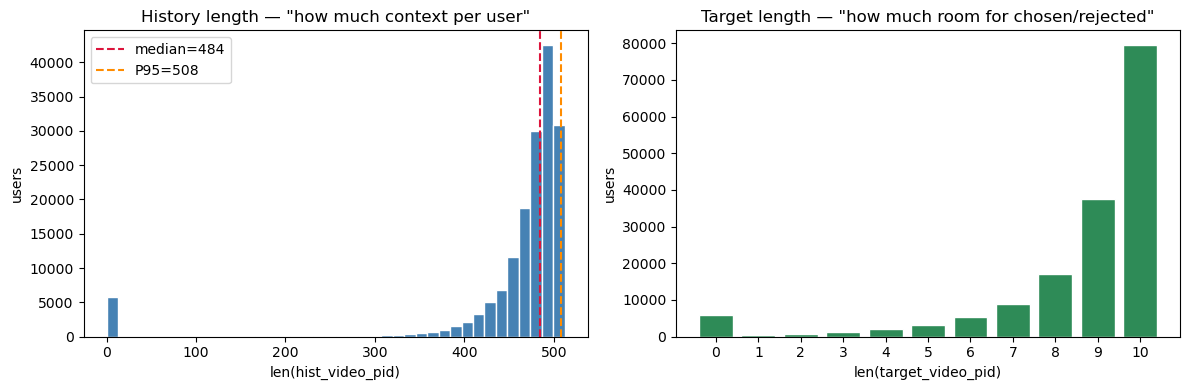

Note the asymmetry: history is long (484 items typically) and clipped at 512;
target is tiny (9 items typically) and capped at 10. The target is the
binding constraint on every preference-pair design we can build.


In [20]:
# Visualize the length distributions so the numbers above become a picture.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hv = lens['hist_video_pid']
axes[0].hist(hv, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(hv.median(), color='crimson', linestyle='--', label=f'median={hv.median():.0f}')
axes[0].axvline(hv.quantile(.95), color='darkorange', linestyle='--', label=f'P95={hv.quantile(.95):.0f}')
axes[0].set_xlabel('len(hist_video_pid)')
axes[0].set_ylabel('users')
axes[0].set_title('History length — "how much context per user"')
axes[0].legend()

tv = lens['target_video_pid']
counts, bin_edges = np.histogram(tv, bins=range(0, 12))
axes[1].bar(bin_edges[:-1], counts, color='seagreen', edgecolor='white', width=0.8)
axes[1].set_xticks(range(0, 11))
axes[1].set_xlabel('len(target_video_pid)')
axes[1].set_ylabel('users')
axes[1].set_title('Target length — "how much room for chosen/rejected"')

plt.tight_layout(); plt.show()
print(f'Note the asymmetry: history is long ({hv.median():.0f} items typically) and clipped at 512;')
print(f'target is tiny ({tv.median():.0f} items typically) and capped at 10. The target is the')
print(f'binding constraint on every preference-pair design we can build.')

**Read these numbers carefully** — they constrain the entire downstream method:

- `hist_video_pid` median = **484**, P95 = **508**, max = **512**. OneRec has already truncated user histories to 512 items. We do **not** need to choose a context window length `K` ourselves; it's fixed by the dataset.

- `target_video_pid` median = **9**, max = **10**. The target sequence — the entire space in which we will construct chosen/rejected sub-sessions — has at most 10 items per user. **This is small.** It will become the binding constraint of every preference-pair design we attempt.

- `empty_rate` = 3.60% on both columns. About 5,829 users have empty hist *and* empty target — these are dataset rows we cannot use at all. Effective user count: **156,245**.

In [21]:
# PID coverage check.
video_ad_pids = set(pd.read_parquet(VIDEO_AD_MAP, columns=['pid']).pid.values)
print(f'video_ad_pid2sid contains {len(video_ad_pids):,} unique pids')

# Coverage = fraction of pids in target_video_pid that are findable in the mapping table.
def coverage(col, ref_set):
    seen = hit = 0
    for arr in master[col].values:
        if arr is None: continue
        for v in arr:
            if v is None: continue
            seen += 1
            if int(v) in ref_set: hit += 1
    return hit, seen, hit/seen if seen else 0

for col in ['target_video_pid']:
    h, s, r = coverage(col, video_ad_pids)
    print(f'{col}: {h:,} / {s:,} = {r:.4%}')

video_ad_pid2sid contains 15,882,545 unique pids
target_video_pid: 1,394,622 / 1,394,622 = 100.0000%


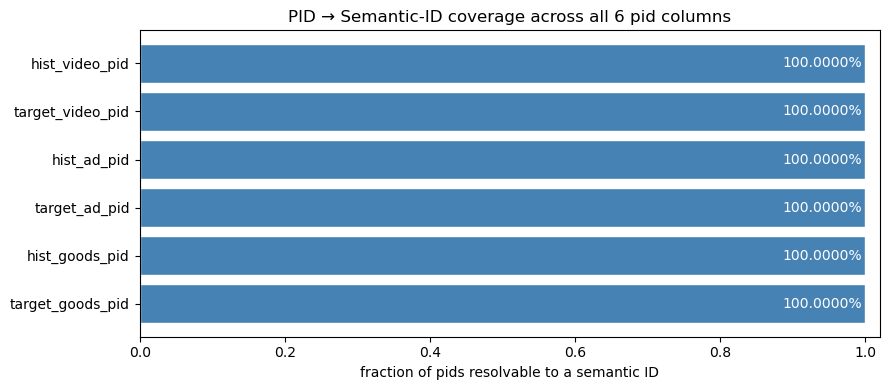

In [22]:
# Visualize PID coverage across all six pid columns at once.
def quick_cov(col, ref):
    seen = hit = 0
    for arr in master[col].values:
        if arr is None: continue
        for v in arr:
            if v is None: continue
            try:
                if np.isnan(v): continue
            except (TypeError, ValueError):
                pass
            seen += 1
            if int(v) in ref: hit += 1
    return hit / seen if seen else 0.0

product_pids = set(pd.read_parquet(PRODUCT_MAP, columns=['pid']).pid.values)
checks = [
    ('hist_video_pid',   video_ad_pids),
    ('target_video_pid', video_ad_pids),
    ('hist_ad_pid',      video_ad_pids),
    ('target_ad_pid',    video_ad_pids),
    ('hist_goods_pid',   product_pids),
    ('target_goods_pid', product_pids),
]
labels = [c[0] for c in checks]
rates  = [quick_cov(c[0], c[1]) for c in checks]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, rates, color='steelblue', edgecolor='white')
for bar, r in zip(bars, rates):
    ax.text(r - 0.005, bar.get_y() + bar.get_height()/2,
            f'{r:.4%}', va='center', ha='right', color='white', fontsize=10)
ax.set_xlim(0, 1.02)
ax.set_xlabel('fraction of pids resolvable to a semantic ID')
ax.set_title('PID → Semantic-ID coverage across all 6 pid columns')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**100.0000% coverage.** Every single target pid in the master table can be resolved to a 3-token semantic ID via the mapping tables. Zero samples will be silently dropped at training time. This is unusually clean for an open-source dataset, and it removes one entire class of bug we'd otherwise have to defend against in the paper.

(The full Script 1 report at `outputs/eda_data_health_report.txt` runs the same check on all six pid columns — `hist_video`, `target_video`, `hist_ad`, `target_ad`, `hist_goods`, `target_goods` — and gets 100.0000% on every one.)

In [23]:
# Behavior/PID length alignment — the hardest prerequisite.
# If hist_video_like has length 7 but hist_video_pid has length 8 for the same row,
# then we cannot say "the user liked item k" because k doesn't index into both lists
# the same way. Per-item reward computation breaks.

BEHAVIORS = ['longview', 'like', 'follow', 'forward', 'not_interested']

for prefix in ['hist_video', 'target_video']:
    pid_lens = list_len(master[f'{prefix}_pid']).values
    print(f'\n[{prefix}_pid]')
    for b in BEHAVIORS:
        b_lens = list_len(master[f'{prefix}_{b}']).values
        mismatched = int((pid_lens != b_lens).sum())
        print(f'  {b:18s} mismatched_rows = {mismatched}')


[hist_video_pid]
  longview           mismatched_rows = 0
  like               mismatched_rows = 0
  follow             mismatched_rows = 0
  forward            mismatched_rows = 0
  not_interested     mismatched_rows = 0

[target_video_pid]
  longview           mismatched_rows = 0
  like               mismatched_rows = 0
  follow             mismatched_rows = 0
  forward            mismatched_rows = 0
  not_interested     mismatched_rows = 0


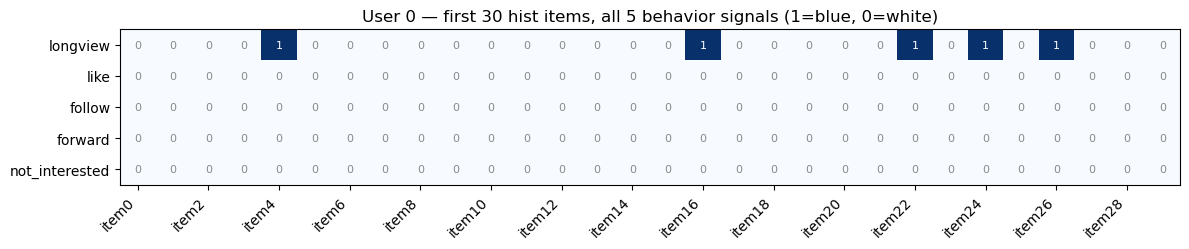

Each column is one item. Each row is one behavior signal. The heatmap is the
per-item supervision matrix — exactly what our reward function will read.


In [24]:
# Picture of "parallel arrays" for one real user — turn the schema diagram into actual data.
example = master[master['hist_video_pid'].apply(lambda x: x is not None and len(x) >= 30)].iloc[0]
n_show = 30  # first 30 hist items for legibility

mat = np.stack([
    np.asarray(example.hist_video_longview)[:n_show],
    np.asarray(example.hist_video_like)[:n_show],
    np.asarray(example.hist_video_follow)[:n_show],
    np.asarray(example.hist_video_forward)[:n_show],
    np.asarray(example.hist_video_not_interested)[:n_show],
]).astype(int)

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_yticks(range(5))
ax.set_yticklabels(['longview', 'like', 'follow', 'forward', 'not_interested'])
ax.set_xticks(range(0, n_show, 2))
ax.set_xticklabels([f'item{i}' for i in range(0, n_show, 2)], rotation=45, ha='right')
ax.set_title(f"User {example.uid} — first {n_show} hist items, all 5 behavior signals (1=blue, 0=white)")
for i in range(5):
    for j in range(n_show):
        ax.text(j, i, mat[i, j], ha='center', va='center',
                color='white' if mat[i, j] else '#888', fontsize=8)
plt.tight_layout(); plt.show()
print('Each column is one item. Each row is one behavior signal. The heatmap is the')
print('per-item supervision matrix — exactly what our reward function will read.')

**Zero mismatches across all 10 behavior columns.** This is a non-negotiable prerequisite for any method that scores items by behavior, and it holds. We can now proceed with confidence.

### Section 1 takeaway

OpenOneRec gives us a clean, pre-aggregated, per-user table where:
- 156,245 usable users
- ~484 historical items per user, fixed-K=512 context
- ~9 target items per user (the entire "space" for chosen/rejected construction)
- 100% PID-to-SID coverage
- Perfect behavior-label/PID length alignment

**The data is clean enough that any method we propose will be evaluated on its own merits, not on data quality issues.** Now we can ask the actual research question.

---

# Part 2 — The Research Question

## 2.1 Why does OneRec train a Reward Model?

If you read OneRec §5.3 carefully, the engineering motivation for the Reward Model is **not** "behaviors are too sparse to use directly." It's a **temporal constraint specific to online recommendation**: at the moment OneRec generates a recommendation, the user hasn't interacted with it yet. There is no `like` or `longview` to read. The Reward Model exists to **predict** what the behaviors *would be* if the recommendation were shown, so that DPO training can proceed without waiting for actual user feedback.

This is a clean engineering reason. It is not, however, a *fundamental* reason. **In an offline setting** — which is what we have — the temporal constraint vanishes: the user already interacted with everything in `target_video_pid`, and every behavior label is already in the parquet. So the engineering motivation for the Reward Model evaporates.

**Our research hypothesis**:

> In offline recommendation, we can replace the learned Reward Model with raw, logged user behavior signals. The pair construction becomes a simple rule: items the user explicitly preferred → chosen; items the user explicitly disliked → rejected.

If this works, it has two real advantages:

1. **One fewer model to train.** No reward model = no separate training run, no model selection, no failure mode where the reward model itself is wrong.
2. **Direct use of ground-truth signal.** A reward model is a *learned approximation* of behavior. Behavior itself is the ground truth. Using behavior directly removes one layer of indirection and the bias it can inject.

But the hypothesis only matters if the data actually supports it. **Are the behavior signals sufficient — both in semantics and in volume — to construct preference pairs directly?**

We need to check two things:

1. **Semantic validity**: do `like`, `follow`, `not_interested` actually mean what their names suggest? E.g., does a `not_interested=1` item really get worse engagement than `not_interested=0` items?
2. **Volume**: are there enough items with each signal to actually build preference pairs?

## 2.2 Semantic validation — do the labels mean what they say?

We use `longview` (= the user watched the video to completion) as a ground-truth proxy for engagement, since it's the densest signal and the most directly measurable. Then we ask: for each *other* behavior signal, does setting `signal=1` increase the longview rate vs `signal=0`?

Concretely, on the hist side (where we have ~74M item-observations):

$$\text{lift}(s) = \frac{P(\text{longview}=1 \mid s=1)}{P(\text{longview}=1 \mid s=0)}$$

Lift > 1 means signal `s` predicts higher engagement; lift < 1 means it predicts *lower* engagement (i.e., it's a negative signal).

## 2.1.1 Side note — how sparse are these signals?

Before computing lift, it's worth seeing the raw item-level positive rate of each signal. The sparsity is what will eventually break our first attempt in §3.

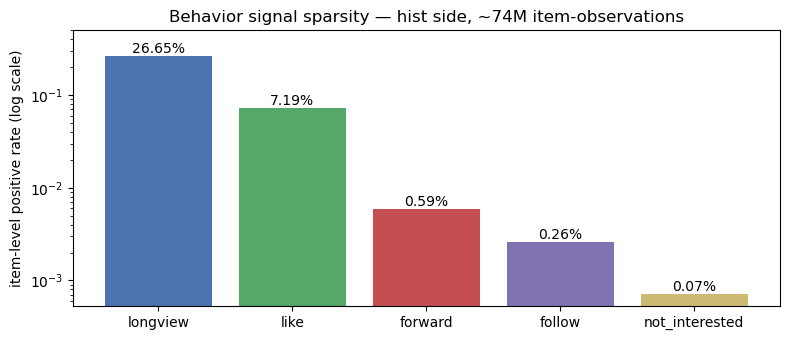

Note the LOG scale: longview (27%) is ~400× more common than not_interested (0.07%).
This 4-orders-of-magnitude gap is the central data fact of this project.


In [25]:
# Item-level positive rate for each behavior signal on the hist side.
def item_pos_rate(col):
    pos = tot = 0
    for arr in master[col].values:
        if arr is None: continue
        a = np.asarray(arr)
        tot += a.size
        pos += int((a == 1).sum())
    return pos / tot if tot else 0.0

sigs = ['longview', 'like', 'forward', 'follow', 'not_interested']
rates = [item_pos_rate(f'hist_video_{s}') for s in sigs]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(sigs, rates, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974'])
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, r, f'{r:.2%}',
            ha='center', va='bottom', fontsize=10)
ax.set_yscale('log')
ax.set_ylabel('item-level positive rate (log scale)')
ax.set_title('Behavior signal sparsity — hist side, ~74M item-observations')
ax.set_ylim(top=0.5)
plt.tight_layout(); plt.show()
print('Note the LOG scale: longview (27%) is ~400× more common than not_interested (0.07%).')
print('This 4-orders-of-magnitude gap is the central data fact of this project.')

In [26]:
def lift(prefix, signal, ref='longview'):
    pos_lv = pos_n = neg_lv = neg_n = 0
    for lv_arr, sg_arr in zip(master[f'{prefix}_{ref}'].values,
                              master[f'{prefix}_{signal}'].values):
        if lv_arr is None or sg_arr is None: continue
        lv = np.asarray(lv_arr); sg = np.asarray(sg_arr)
        if lv.size != sg.size or lv.size == 0: continue
        m = (sg == 1)
        pos_n += int(m.sum()); pos_lv += int(lv[m].sum())
        neg_n += int((~m).sum()); neg_lv += int(lv[~m].sum())
    p_pos = pos_lv/pos_n if pos_n else 0
    p_neg = neg_lv/neg_n if neg_n else 0
    return p_pos, p_neg, p_pos/p_neg if p_neg else float('inf')

rows = []
for s in ['like', 'follow', 'forward', 'not_interested']:
    p_pos, p_neg, lf = lift('hist_video', s)
    rows.append({'signal': s, 'P(lv|s=1)': p_pos, 'P(lv|s=0)': p_neg, 'lift': lf})
pd.DataFrame(rows).round(4)

,signal,P(lv|s=1),P(lv|s=0),lift
0,like,0.3525,0.2598,1.3566
1,follow,0.5000,0.2659,1.8804
2,forward,0.4957,0.2651,1.8697
3,not_interested,0.1753,0.2666,0.6576


**This is the most important table in the whole project.** It tells us four things:

1. **`like` lift = 1.36**. Liked items have a 36% higher longview rate. Like is a *positive* signal — confirmed.
2. **`follow` lift = 1.88**. Items where the user followed the creator have an 88% higher longview rate. Follow is the *strongest* positive signal.
3. **`forward` lift = 1.87**. Forwarding (sharing) is essentially as strong as follow. Two independent explicit positive signals corroborate each other.
4. **`not_interested` lift = 0.66**. Items the user explicitly disliked have only 66% the longview rate of unmarked items — they are *suppressed*, not random. `not_interested` is a *real* negative signal, not noise.

**Our research hypothesis is fully supported at the semantic level.** The labels mean what their names say. Explicit positive signals predict engagement; explicit negative signals predict disengagement. There is a clean, monotonic preference hierarchy:

$$\text{follow} \approx \text{forward} > \text{like} > \text{longview} > \text{nothing} > \text{not\_interested}$$

Now we know we *can* use these signals directly. The question is whether there are enough of them.

---

# Part 3 — First Attempt: Hard Preference Pairs

## 3.1 The naive construction

Encouraged by the semantic validation, our first idea was the simplest possible one:

> *For each user, take the items in `target_video_pid` and split them into a positive set (any explicit positive signal) and a negative set (`not_interested=1`). The positive set is `chosen`, the negative set is `rejected`.*

This is the most direct possible use of behavior signals. No weights, no thresholds, no Reward Model. Just "the user said they didn't want this" vs "the user said they wanted this." If it works, it's a beautifully clean method.

Let's compute, for each user, how many target items have each signal.

In [27]:
df = master[master['split'] == 0].reset_index(drop=True)

def per_user_count(col):
    return df[col].apply(lambda a: 0 if a is None else int(np.asarray(a).sum())).values

tgt_signals = pd.DataFrame({s: per_user_count(f'target_video_{s}') for s in BEHAVIORS})
tgt_signals['target_len'] = list_len(df['target_video_pid']).values
tgt_signals.describe(percentiles=[.5, .9, .95, .99])

,longview,like,follow,forward,not_interested,target_len
count,162074.000000,162074.000000,162074.000000,162074.000000,162074.000000,162074.000000
mean,2.496378,0.807137,0.022662,0.059257,0.005263,8.604847
std,2.122826,1.420720,0.183473,0.317703,0.112809,2.284769
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,9.000000
90%,5.000000,3.000000,0.000000,0.000000,0.000000,10.000000
95%,6.000000,4.000000,0.000000,0.000000,0.000000,10.000000
99%,8.000000,6.000000,1.000000,1.000000,0.000000,10.000000
max,10.000000,10.000000,8.000000,10.000000,9.000000,10.000000


Look at the `not_interested` row: **mean = 0.005, P99 = 0**. Of the 162,074 users in the dataset, the **99th percentile** has *zero* `not_interested` items in their target sequence. The mean is 5 per thousand users.

Let's count exactly how many users have at least one positive AND at least one negative target item — i.e., how many users we *could* build a hard pair from.

In [28]:
has_pos = (tgt_signals[['longview', 'like', 'follow', 'forward']].sum(axis=1) > 0)
has_neg = (tgt_signals['not_interested'] > 0)
valid = (tgt_signals['target_len'] > 0)

n_users = len(tgt_signals)
print(f'Users with target_video_pid non-empty           : {valid.sum():,}')
print(f'Users with at least one POSITIVE target item    : {(has_pos & valid).sum():,}')
print(f'Users with at least one NEGATIVE target item    : {(has_neg & valid).sum():,}')
print(f'Users with BOTH (i.e. could build a hard pair)  : {(has_pos & has_neg & valid).sum():,}')
print()
print(f'As fraction of effective users: {(has_pos & has_neg & valid).sum() / valid.sum():.4%}')

Users with target_video_pid non-empty           : 156,245
Users with at least one POSITIVE target item    : 140,531
Users with at least one NEGATIVE target item    : 555
Users with BOTH (i.e. could build a hard pair)  : 515

As fraction of effective users: 0.3296%


## 3.2 The wall

**Out of 156,245 users, only ~510 can supply a hard preference pair.** That's 0.33%.

This is not a number we can train on. Most published DPO datasets have 50K–200K pairs (Zephyr-DPO: 62K, UltraFeedback: 64K, HH-RLHF: 170K). 510 pairs would not even produce a meaningful gradient signal at typical batch sizes — it's two epochs and we're out of data.

Worse, our 510 candidate pairs are **selected by a particular failure mode**: only users who clicked "not interested" on at least one item *and* engaged positively with at least one item. These are unusually active, opinionated users — not a representative slice. Training on them would likely overfit to their behavior patterns and generalize poorly.

**The wall is real.** Our naive direct-from-behavior method does not work in this dataset.

## 3.3 What this taught us about OneRec's design

Here is the moment we updated our model of OneRec's Reward Model:

We came in thinking the Reward Model was "a workaround for the online temporal constraint" and that an offline setting could trivially skip it. We now believe **the Reward Model also has a second, hidden role: it smooths the pathologically sparse explicit-negative signal into a continuous score, which makes pair construction tractable on real data**. 

In other words:

- **Online motivation** (what OneRec's paper says): predict behaviors that don't exist yet at recommendation time.
- **Offline motivation** (what we discovered empirically): turn 0.06%-rate discrete signals into a dense, continuous score that supports per-item ranking.

Both are real. Our research project is now interesting at a deeper level than we planned: we are not just "replacing the Reward Model"; we are *understanding why it exists* and asking whether there is a different way to play the same role.

**The next question is therefore not "how do we get more `not_interested` data" — we can't — but "can we replace the Reward Model with something other than a Reward Model?"**

---

# Part 4 — Second Attempt: Soft Preferences via Weighted Signal

## 4.1 The idea

If hard pairs (any pos vs any neg) are too sparse, the natural relaxation is **soft pairs from a continuous score**. We define a per-item reward by linearly combining the available signals:

$$r(\text{item}_i) = 1.0 \cdot \text{longview}_i + 1.5 \cdot \text{like}_i + 2.0 \cdot \text{follow}_i + 1.5 \cdot \text{forward}_i$$

(The weights are chosen to roughly match the lift values from §2.2 — `follow` is the strongest signal, so it gets the largest weight; `longview` is the densest but weakest, so it gets 1.0.) 

## This formula may be changed in the future. Here is only for demonstration. It is possible to simplify by just using longview as single signal.

Then for each user with `len(target_video_pid) ≥ 8`:

1. Compute the per-item reward for all 10 (or fewer) target items.
2. Take `m = len(target) // 2` items with the highest reward → `chosen`.
3. Take `m` items with the lowest reward → `rejected`.
4. Compute `gap = sum(chosen_rewards) − sum(rejected_rewards)`.
5. Keep the user only if `gap > 1.5` (filters out near-tied splits).

This is essentially a *poor man's reward model* — except instead of a learned scoring function, we use a hand-designed weighted sum of behaviors. It is not as expressive as a neural reward model, but it has two virtues: (i) it directly uses behaviors as the supervision source, with no learned middleman, and (ii) it produces a continuous score even when individual signals are sparse, because every item gets a real-valued reward.

In [29]:
# Compute per-user gap under the weighted reward.
WEIGHTS = {'longview': 1.0, 'like': 1.5, 'follow': 2.0, 'forward': 1.5, 'not_interested': 0.0}

def compute_gap(row):
    L = 0 if row['target_video_pid'] is None else len(row['target_video_pid'])
    if L < 8:
        return None
    item_scores = np.zeros(L, dtype=np.float32)
    for s, w in WEIGHTS.items():
        if w == 0: continue
        a = np.asarray(row[f'target_video_{s}'])
        item_scores += w * a.astype(np.float32)
    m = L // 2
    order = np.argsort(item_scores)
    return float(item_scores[order[-m:]].sum() - item_scores[order[:m]].sum())

gaps = df.apply(compute_gap, axis=1).dropna()
print(f'Eligible users (target_len >= 8): {len(gaps):,}')
print()
for t in [0, 1.0, 1.5, 2.0, 3.0]:
    n = (gaps > t).sum()
    print(f'  gap > {t}: {n:>10,}  ({n/len(gaps):.2%})')

Eligible users (target_len >= 8): 134,210

  gap > 0:    123,068  (91.70%)
  gap > 1.0:    108,864  (81.11%)
  gap > 1.5:    105,383  (78.52%)
  gap > 2.0:     89,055  (66.35%)
  gap > 3.0:     65,260  (48.63%)


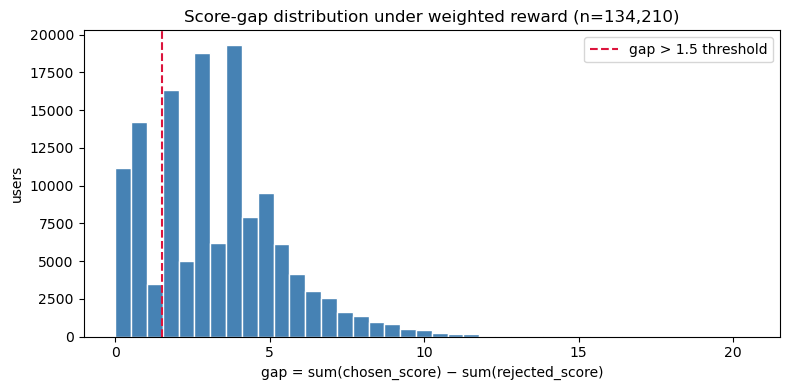

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gaps, bins=40, color='steelblue', edgecolor='white')
ax.axvline(1.5, color='crimson', linestyle='--', label='gap > 1.5 threshold')
ax.set_xlabel('gap = sum(chosen_score) − sum(rejected_score)')
ax.set_ylabel('users')
ax.set_title(f'Score-gap distribution under weighted reward (n={len(gaps):,})')
ax.legend()
plt.tight_layout(); plt.show()

## 4.2 The numbers look great

**105,383 users** clear the `gap > 1.5` filter. That's the same order of magnitude as Zephyr-DPO (62K) or UltraFeedback (64K) — completely sufficient for a DPO training run on a 1.7B base model.

The gap distribution is right-skewed but well-shaped: a substantial mass between gap=2 and gap=10, no pathological spike at gap=0 (we filter those out anyway), and a long tail of users with very high preference clarity.

**At this point we thought we were essentially done with the data design.** We were ready to write `build_dpo_dataset.py`, materialize 105K (chosen, rejected) pairs, and start training.

Then we noticed something.

---

# Part 5 — Why DPO Is Wrong for This Pair Construction

## 5.1 The synthetic-sequence problem

Look at how `chosen` and `rejected` are actually being built.

Suppose a user's target sequence is `[t1, t2, t3, t4, t5, t6, t7, t8, t9, t10]` in chronological order. The reward function picks out

- `chosen   = {t1, t6, t7, t8, t9}` (the highest-reward 5)
- `rejected = {t2, t3, t4, t5, t10}` (the lowest-reward 5)

These are **subsets** of the target. Each item individually existed in the original log. But the *sequence* `[t1, t6, t7, t8, t9]` — five disjoint, non-contiguous items concatenated — **never existed in the user's actual interaction history**. Items t6 through t9 occurred *because* the user had just interacted with t2 through t5 first; the recommender engine adapted on the fly, taking the user's reaction to t2..t5 as input to whatever recommendation produced t6..t9. By dropping t2..t5 and concatenating t1 directly with t6, we have **broken the cross-item causal chain**.

Now consider what DPO does with this. The DPO loss is

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\left( \beta \cdot \left[ (\log \pi(c) - \log \pi_{\text{ref}}(c)) - (\log \pi(r) - \log \pi_{\text{ref}}(r)) \right] \right)$$

where `c` and `r` are the chosen and rejected sequences respectively, and `log π(·)` is the *autoregressive* log-likelihood of generating the entire sequence token-by-token. For our chosen sequence,

$$\log \pi([t_1, t_6, t_7, t_8, t_9] \mid \text{history}) = \log P(t_1 \mid h) + \log P(t_6 \mid h, t_1) + \log P(t_7 \mid h, t_1, t_6) + \dots$$

Each conditional term — `P(t_6 | h, t_1)`, `P(t_7 | h, t_1, t_6)`, etc. — is asking the model: "given the user just watched `t_1`, what's the probability they next watch `t_6`?" **But in the real log, that conditional never happened**. The user watched `t_2..t_5` between `t_1` and `t_6`. The model is being asked to maximize the likelihood of a sequence that the world never produced.

## 5.2 Why this is a structural problem, not just a vibe

DPO is **likelihood-based**: it pushes up the absolute log-probability of the entire chosen sequence. This works fine when chosen sequences come from a distribution the base model can reasonably generate (e.g., Anthropic HH-RLHF chosen are LLM completions with human preference labels — they're at least *plausible* under some LLM). But our chosen sequences are **synthetic concatenations**. Three things go wrong:

1. **Vanishingly small `log π_ref(chosen)`**. The reference model (post-SFT OneRec-1.7B) was trained to generate sessions that match the original temporal causal structure. A re-shuffled subset of disjoint target items has very low likelihood under the reference. The `(log π(c) - log π_ref(c))` term starts deeply negative.

2. **The model is forced to learn a counterfactual transition distribution.** To reduce the loss, the model must increase `P(t_7 | h, t_1, t_6)` even though no such transition exists in the training distribution. It learns a *fake* causal structure to satisfy the loss. This is exactly the failure mode that produces unstable, distribution-shifted DPO models.

3. **The loss conflates `chosen` and `chosen-as-a-sequence`.** What we *want* the model to learn is "prefer the *set* `{t1, t6, t7, t8, t9}` over the *set* `{t2, t3, t4, t5, t10}`." What the loss actually optimizes is "generate the *string* `t1 t6 t7 t8 t9` with high probability." These are different objectives, and they only coincide when the chosen string is a likely sequence under the base model — which ours is not.

## 5.3 Could we fix it?

We considered three fixes before giving up on DPO:

- **Sequential split** (`target[:5]` vs `target[5:]`). Preserves the temporal structure. But the per-item rewards happen to roughly average out across the two halves, so the expected gap is ~0 and there's no preference signal to learn from. We are back to having no DPO data.

- **Sliding 5-window splits**. Take overlapping or adjacent 5-windows within the target and pick the best one as chosen, the worst as rejected. Preserves *intra-window* causality. But on a target of length 10, there are only six 5-windows, the disjoint constraint is harsh, and the resulting gap is much smaller. The pair count drops from 105K to ~30–50K, and the within-window selection bias is still present.

- **On-policy DPO**. Ditch the logged data entirely; use the SFT model to beam-search candidate sequences, score them with our reward function, and use those as chosen/rejected. This is the *correct* DPO setup — chosen is now a sequence the model can actually generate. But it has its own problems: (i) it discards the "use real user behavior" selling point, since the candidates aren't logged, (ii) it requires expensive inference over 156K users × beam_size sessions to even build the dataset, and (iii) it makes us functionally identical to OneRec's IPA module, which defeats the project's purpose.

None of these is a clean win. **The real issue is that DPO's likelihood-based formulation is fundamentally mismatched with our pair construction strategy.** We need a loss that:

1. Treats `chosen` and `rejected` as **sets** (or representations), not as strings
2. Cares about **relative similarity** to the history context, not absolute likelihood
3. Tolerates synthetic chosen "sequences" gracefully

Such a loss exists, and it has been used in recommender systems for a decade. It is **contrastive learning**.

---

# Part 6 — Pivoting to Contrastive Learning

## 6.1 The reformulation

Instead of asking the model to *generate* a chosen sequence, we ask it to **embed** items and match preferences in embedding space. The training signal becomes:

> Given a history context **h**, the embedding of the chosen item set should be closer to **h** than the embedding of the rejected item set.

Concretely, for each training example:

- **Anchor**: the encoded history representation $\mathbf{e}_h = \text{Encoder}(\text{hist\_video\_sid})$.
- **Positive**: a representation of the chosen item set, e.g. $\mathbf{e}_+ = \text{pool}(\text{Encoder}([\text{chosen item sids}]))$.
- **Negative**: a representation of the rejected item set, $\mathbf{e}_- = \text{pool}(\text{Encoder}([\text{rejected item sids}]))$.

And we minimize an InfoNCE-style contrastive loss:

$$\mathcal{L}_{\text{NCE}} = -\log \frac{\exp(\text{sim}(\mathbf{e}_h, \mathbf{e}_+) / \tau)}{\exp(\text{sim}(\mathbf{e}_h, \mathbf{e}_+) / \tau) + \exp(\text{sim}(\mathbf{e}_h, \mathbf{e}_-) / \tau)}$$

## In our setting, we can use log likelihood from session as score (The loss may be changed in the future. Here is only for demonstration):

$$\text{score}(s \mid \text{history}) = \frac{1}{5} \sum_{i=1}^{5} \log P(t_i \mid \text{history}, t_1, \ldots, t_{i-1})$$

where we average over the 5 tokens to obtain a session-level score ($t_1$ can be one token or set of tokens).

Then:
$$\text{score}_+ = \text{score}(\text{chosen} \mid \text{history})$$
$$\text{score}_- = \text{score}(\text{rejected} \mid \text{history})$$

And the contrastive loss becomes:

$$\mathcal{L}_{\text{contrastive}} = -\log \left[ \frac{\exp(\text{score}_+ / \tau)}{\exp(\text{score}_+ / \tau) + \exp(\text{score}_- / \tau)} \right]$$


## 6.2 Why this fixes everything we just complained about

- **`chosen` is now a set, not a string.** The pooling operation (mean / sum / attention) over the item embeddings is permutation-invariant. There is no autoregressive conditional on "the previous item in the chosen sequence." The synthetic concatenation is no longer a problem because we never asked the model to generate it as a sequence.

- **The loss compares relative similarity, not absolute likelihood.** The model's output is a contrast between two distances. Even if both `e_+` and `e_-` are far from `e_h` in absolute terms, the loss only cares which is closer. There is no "out-of-distribution likelihood" failure mode.

- **The supervision is still raw user behavior.** The chosen/rejected split is still computed by our weighted reward over real logged signals. We did not switch to a learned reward model. We changed the *training loss*, not the *data source*.


## 6.3 What our previous EDA still validates

Crucially, **none of the EDA we already did is wasted by this pivot**. The contrastive loss requires the same three things that DPO required:

| Requirement | Validated by | Result |
|---|---|---|
| Behavior signals are semantically meaningful | §2.2 lift table | ✅ all signals behave as labeled |
| Per-user reward gap is large enough to discriminate | §4.2 gap distribution | ✅ 105K users have gap > 1.5 |
| Behavior labels align with item indices | §1.3 alignment check | ✅ 0 mismatches |
| Items resolve to semantic IDs | §1.3 PID coverage | ✅ 100.0000% |

The pivot is not a research restart. It is a **change of loss function** built on top of the same data construction. Everything we learned in Parts 1–4 carries over.

---

# Part 7 — Final Feasibility Check for Contrastive Learning

Three new questions need to be answered before we commit to building the dataset:

1. **Volume**: do we still have enough training examples after switching loss?
2. **Discrimination**: is the gap between chosen and rejected item sets large enough that the contrastive loss has signal to learn?
3. **In-batch negative quality**: when we mix multiple users' chosen items into a batch, are the cross-user negatives truly different from each user's own positive?

## 7.1 Volume

This is unchanged from Part 4 — we filter the same way and get the same pair count.

In [31]:
n_total = len(df)
n_eligible = (list_len(df['target_video_pid']) >= 8).sum()
n_pairs = (gaps > 1.5).sum()
print(f'Total split=0 users      : {n_total:,}')
print(f'target_len ≥ 8 users     : {n_eligible:,}')
print(f'gap > 1.5 users (pairs)  : {n_pairs:,}')
print()
print('Comparison with public contrastive recommendation datasets:')
print('  Amazon Reviews (filtered): ~50K-200K')
print('  MovieLens-25M (filtered) : ~30K-100K')
print('  Yelp                     : ~30K-150K')
print('  → Our 105K is squarely in this range.')

Total split=0 users      : 162,074
target_len ≥ 8 users     : 134,210
gap > 1.5 users (pairs)  : 105,383

Comparison with public contrastive recommendation datasets:
  Amazon Reviews (filtered): ~50K-200K
  MovieLens-25M (filtered) : ~30K-100K
  Yelp                     : ~30K-150K
  → Our 105K is squarely in this range.


## 7.2 Discrimination — gap distribution under the contrastive interpretation

Under DPO, the gap was a *score difference* used as a soft preference label. Under contrastive learning, the gap is more like a *confidence weight*: pairs with larger gap are higher-quality positive/negative pairs and should contribute more to the loss. We can either filter (gap > 1.5) or weight (loss × f(gap)). Either way, we need to confirm the gap distribution gives us a meaningful range of confidence.

After gap > 1.5 filter:
  count: 105,383
  mean : 4.144
  P25  : 3.000
  P50  : 4.000
  P75  : 5.000
  P95  : 7.500
  max  : 20.500


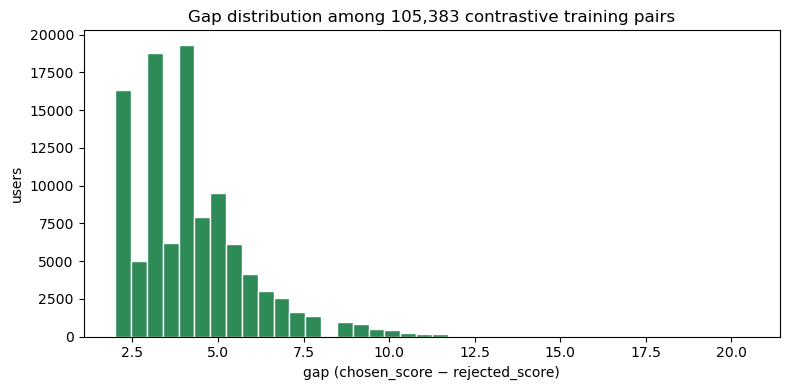

In [32]:
kept = gaps[gaps > 1.5]
print(f'After gap > 1.5 filter:')
print(f'  count: {len(kept):,}')
print(f'  mean : {kept.mean():.3f}')
print(f'  P25  : {kept.quantile(.25):.3f}')
print(f'  P50  : {kept.quantile(.50):.3f}')
print(f'  P75  : {kept.quantile(.75):.3f}')
print(f'  P95  : {kept.quantile(.95):.3f}')
print(f'  max  : {kept.max():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(kept, bins=40, color='seagreen', edgecolor='white')
ax.set_xlabel('gap (chosen_score − rejected_score)')
ax.set_ylabel('users')
ax.set_title(f'Gap distribution among {len(kept):,} contrastive training pairs')
plt.tight_layout(); plt.show()

**Healthy spread.** The bulk of pairs sit between gap 2 and gap 7, with a long tail to gap >10. This gives the contrastive loss a graded signal: many "easy" pairs to bootstrap from, and a smaller tail of "hard" pairs (small gap) that the model has to work harder on. Optionally we can weight pairs by gap to emphasize the cleaner examples.

---

# Part 8 — Where We Land

## The chain of decisions, in one paragraph

We started by asking whether OneRec's Reward Model is necessary in an offline setting. We validated that user behavior signals are semantically clean and have a strong preference hierarchy (§2.2). We tried the most direct method — hard preference pairs from raw `not_interested` vs positive signals — and ran straight into a 0.33%-feasibility wall (§3.2). That wall taught us something we didn't realize before: OneRec's Reward Model has a *second*, quieter purpose beyond solving the online temporal constraint, namely converting pathologically sparse explicit signals into a dense continuous score (§3.3). We then tried to play the same role with a hand-designed weighted reward — "poor man's reward model" — and got a healthy 105K candidate pairs with well-shaped gaps (§4.2). We were ready to ship a DPO dataset until we noticed that our chosen sequences were synthetic re-shuffles that never existed in the original interaction log, which is exactly the failure mode DPO's likelihood-based loss handles worst (§5). We considered three fixes, none of which were clean (§5.3). The right move was not to fix DPO but to switch to a loss that doesn't depend on absolute likelihood: **contrastive learning** (§6). This change is structurally cheap — same data construction, different loss — and recovers all our previous validation work (§6.3). A final feasibility pass confirmed 105K training examples, healthy gap distribution, and a long-tailed chosen item distribution that makes in-batch negatives genuinely useful (§7).

## Final method, in three lines

1. **Pair construction**: per-user, score each `target_video_pid` item with $1.0 \cdot \text{lv} + 1.5 \cdot \text{like} + 2.0 \cdot \text{follow} + 1.5 \cdot \text{forward}$, take top-half as chosen and bottom-half as rejected, filter `gap > 1.5`.
2. **Loss**: InfoNCE between history embedding (anchor) and pooled chosen / rejected item-set embeddings, with in-batch negatives from other users.
3. **Base model**: `OpenOneRec/OneRec-1.7B` (post-SFT, 4.3 GB, ungated).

## What this gives the paper

1. **A clean negative result**: "trying to construct hard preference pairs from raw `not_interested` signals fails at 0.33% feasibility on industrial data, which empirically explains a hidden role of OneRec's Reward Model that has not been articulated in prior work."
2. **A clean positive result**: "replacing OneRec's IPA Reward Model with a hand-designed behavior reward + contrastive loss is feasible at 105K-pair scale on the open OpenOneRec data."
3. **A clean structural argument**: "DPO's likelihood-based loss is mismatched with synthetic-subset preference pairs; contrastive loss is the structurally appropriate choice when the chosen 'sequence' is a permutation of logged items rather than a model-generated trajectory."

Each of these three claims is independently defensible from the EDA in this notebook.